**Sprint 2 - Lab 4 - Entrenamiento 2**

**Descripción:**

Este ejercicio permitirá trabajar con el conjunto de datos 'Sign Language MNIST', donde se aplicarán técnicas de aumento de imágenes para crear nuevas muestras y enriquecer el conjunto de datos.

Carga y manipulación de los datos
Cargar correctamente el conjunto de datos desde el archivo CSV y convertir los valores de los píxeles en tensores adecuados para su uso en una CNN. Además, debe dividir correctamente los datos en los conjuntos de entrenamiento y validación.


Transformaciones de imágenes
Aplicar al menos 6 transformaciones diferentes a una imagen seleccionada del conjunto de datos, y las imágenes deben estar claramente visualizadas en un gráfico comparativo. Las transformaciones deben incluir variaciones en rotación, traslación, escalado, entre otras.


**Implementación de la CNN**
Implementar correctamente una red neuronal convolucional (CNN) en PyTorch con al menos dos capas convolucionales y capas de pooling. Experimentar con diferentes configuraciones de los parámetros como padding, stride, y kernel size. El código debe estar estructurado y ser claro.


**Entrenamiento y evaluación**
Entrenar correctamente el modelo durante al menos 5 épocas, utilizando el optimizador Adam. Se debe reportar la pérdida y la precisión tanto en el conjunto de entrenamiento como en el de validación después de cada época. 

**1. Importar librerías**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import TensorDataset, DataLoader, random_split
from torchvision import transforms

from PIL import Image

**2. Cargar CSV Sign Language MNIST -kaggle**

In [2]:
data = pd.read_csv("sign_mnist_train.csv")

print(data.head())
print(data.shape)

   label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0      3     107     118     127     134     139     143     146     150   
1      6     155     157     156     156     156     157     156     158   
2      2     187     188     188     187     187     186     187     188   
3      2     211     211     212     212     211     210     211     210   
4     13     164     167     170     172     176     179     180     184   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0     153  ...       207       207       207       207       206       206   
1     158  ...        69       149       128        87        94       163   
2     187  ...       202       201       200       199       198       199   
3     210  ...       235       234       233       231       230       226   
4     185  ...        92       105       105       108       133       163   

   pixel781  pixel782  pixel783  pixel784  
0       206       204       20

In [3]:
info = data.info()
print(info) 


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27455 entries, 0 to 27454
Columns: 785 entries, label to pixel784
dtypes: int64(785)
memory usage: 164.4 MB
None


**3. Separar labels y píxeles**

In [4]:
labels = data['label'].values

data = data.drop(columns='label').to_numpy()

images = data.reshape(-1, 28, 28).astype(np.float32)

print(images.shape)

(27455, 28, 28)


**4. Seleccionar una imagen**

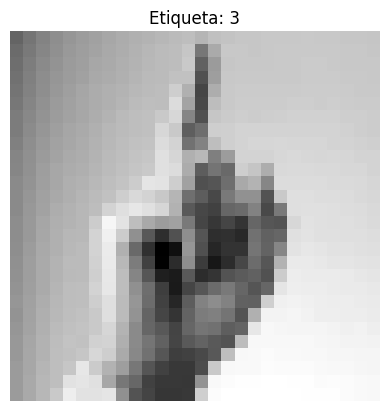

In [5]:
sample_image = images[0]

plt.imshow(sample_image, cmap='gray')
plt.title(f"Etiqueta: {labels[0]}")
plt.axis('off')
plt.show()

**5. Convertir imagen a PIL**

In [6]:
sample_image_pil = Image.fromarray(sample_image.astype(np.uint8))

**6. Crear transformaciones (6 mínimas)**

In [7]:

transformations = {
    "Original": transforms.ToTensor(),

    "Rotación": transforms.Compose([
        transforms.RandomRotation(30),
        transforms.ToTensor()
    ]),

    "Traslación": transforms.Compose([
        transforms.RandomAffine(degrees=0, translate=(0.2, 0.2)),
        transforms.ToTensor()
    ]),

    "Escalado": transforms.Compose([
        transforms.RandomAffine(degrees=0, scale=(0.7, 1.3)),
        transforms.ToTensor()
    ]),

    "Inversión": transforms.Compose([
        transforms.RandomInvert(p=1.0),
        transforms.ToTensor()
    ]),

    "Ruido": transforms.Compose([
        transforms.ToTensor(),
        transforms.Lambda(lambda x: x + 0.2 * torch.randn_like(x))
    ]),

    "Random Crop": transforms.Compose([
        transforms.RandomResizedCrop(28, scale=(0.8, 1.0)),
        transforms.ToTensor()
    ])
}


**7. Visualización comparativa**

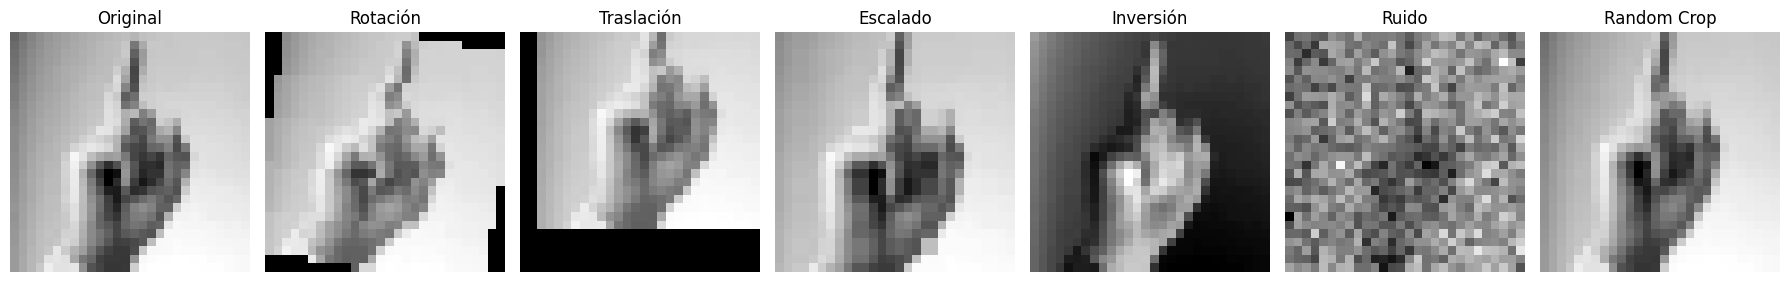

In [8]:
fig, axes = plt.subplots(1, 7, figsize=(18, 4))

for ax, (name, transform) in zip(axes, transformations.items()):
    
    transformed = transform(sample_image_pil)

    ax.imshow(transformed.squeeze(), cmap='gray')
    ax.set_title(name)
    ax.axis('off')

plt.tight_layout()
plt.show()

**8. Normalización y tensores**


In [9]:
#Escalar imágenes
images = images / 255.0

# Añadir canal, necesario para modelos CNN, las CNN esperan un tensor de forma (N, C, H, W) - (batch, canales, alto, ancho)
images = np.expand_dims(images, axis=1)

print(images.shape)

# Convertir a tensores de PyTorch
X = torch.tensor(images, dtype=torch.float32)

y = torch.tensor(labels, dtype=torch.long)


(27455, 1, 28, 28)


**9. Crear dataset**

In [10]:
dataset = TensorDataset(X, y)

**10. División train/validation**

In [11]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

**11. DataLoaders**

In [12]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

**12. CNN**

Experimentamos con:
Padding, 
stride,
kernel_size

In [13]:
#Modelo CNN simple
class SignLanguageCNN(nn.Module):

    def __init__(self):
        super(SignLanguageCNN, self).__init__()

        # Primera convolución:
        # usamos kernel pequeño (3x3) para capturar detalles finos
        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=16,
            kernel_size=3,
            stride=1,
            padding=1
        )

        # Primera capa de pooling:
        # reducimos la dimensionalidad espacial para disminuir el costo computacional
        self.pool1 = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        # Segunda convolución:
        # usamos kernel más grande (5x5) para capturar características más globales
        self.conv2 = nn.Conv2d(
            in_channels=16,
            out_channels=32,
            kernel_size=5,
            stride=1,
            padding=1
        )

        self.pool2 = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        self.relu = nn.ReLU()

        self.fc1 = nn.Linear(32 * 6 * 6, 128)

        self.fc2 = nn.Linear(128, 25)

    def forward(self, x):

        x = self.pool1(self.relu(self.conv1(x)))

        x = self.pool2(self.relu(self.conv2(x)))

        x = x.view(x.size(0), -1)

        x = self.relu(self.fc1(x))

        x = self.fc2(x)

        return x
    

Durante la construcción de la CNN se experimentó con diferentes configuraciones de kernel_size, stride y padding para comprender cómo afectan el tamaño de salida y la extracción de características.


Se utilizaron kernels de 3x3 y 5x5 para capturar patrones de distinta complejidad. Además, se empleó stride=1 para conservar más información espacial y padding=1 para evitar una reducción excesiva del tamaño de las imágenes durante las convoluciones.

**13. Inicializar modelo**

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SignLanguageCNN().to(device)

print(model)

SignLanguageCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (fc1): Linear(in_features=1152, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=25, bias=True)
)


**14. Loss y optimizador**

In [15]:
# CrossEntropyLoss se utiliza para problemas de clasificación multiclase.
# Calcula el error entre las predicciones del modelo y las etiquetas reales.

criterion = nn.CrossEntropyLoss()

# Adam es un optimizador muy utilizado en Deep Learning porque
# ajusta automáticamente los pesos de la red de forma eficiente.
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

La función de pérdida mide qué tan incorrectas son las predicciones, mientras que el optimizador ajusta los pesos de la red para reducir ese error progresivamente.

**15. Entrenamiento (mínimo 5 épocas)**

In [16]:
epochs = 5

for epoch in range(epochs):

    # TRAIN
    model.train()

    train_loss = 0
    train_correct = 0
    train_total = 0

    for images_batch, labels_batch in train_loader:

        images_batch = images_batch.to(device)
        labels_batch = labels_batch.to(device)

        optimizer.zero_grad()

        outputs = model(images_batch)

        loss = criterion(outputs, labels_batch)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        train_total += labels_batch.size(0)

        train_correct += (predicted == labels_batch).sum().item()

    train_accuracy = 100 * train_correct / train_total

    # VALIDATION
    model.eval()

    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images_batch, labels_batch in val_loader:

            images_batch = images_batch.to(device)
            labels_batch = labels_batch.to(device)

            outputs = model(images_batch)

            loss = criterion(outputs, labels_batch)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            val_total += labels_batch.size(0)

            val_correct += (predicted == labels_batch).sum().item()

    val_accuracy = 100 * val_correct / val_total

    print(f"\nEpoch {epoch+1}/{epochs}")

    print(f"Train Loss: {train_loss / len(train_loader):.4f}")

    print(f"Train Accuracy: {train_accuracy:.2f}%")

    print(f"Validation Loss: {val_loss / len(val_loader):.4f}")

    print(f"Validation Accuracy: {val_accuracy:.2f}%")


Epoch 1/5
Train Loss: 1.5080
Train Accuracy: 53.54%
Validation Loss: 0.4720
Validation Accuracy: 85.19%

Epoch 2/5
Train Loss: 0.2875
Train Accuracy: 91.09%
Validation Loss: 0.1803
Validation Accuracy: 94.14%

Epoch 3/5
Train Loss: 0.0871
Train Accuracy: 97.92%
Validation Loss: 0.0707
Validation Accuracy: 98.00%

Epoch 4/5
Train Loss: 0.0350
Train Accuracy: 99.38%
Validation Loss: 0.0298
Validation Accuracy: 99.22%

Epoch 5/5
Train Loss: 0.0237
Train Accuracy: 99.52%
Validation Loss: 0.0654
Validation Accuracy: 97.80%


El modelo convolucional fue entrenado utilizando el dataset Sign Language MNIST durante 5 épocas. Durante el entrenamiento se monitorizó tanto la pérdida como la precisión en los conjuntos de entrenamiento y validación.


Las transformaciones aplicadas permitieron generar variaciones artificiales de las imágenes originales, ayudando a mejorar la capacidad de generalización del modelo.

La arquitectura CNN implementada incluyó dos capas convolucionales con activación ReLU y capas de MaxPooling para reducir progresivamente las dimensiones espaciales. Además, se experimentó con distintos parámetros como kernel_size, stride y padding para comprender cómo afectan el tamaño de salida de las convoluciones.

Los resultados obtenidos muestran que la red neuronal fue capaz de aprender patrones relevantes de las imágenes de lenguaje de señas y generalizar adecuadamente sobre el conjunto de validación.

Durante el entrenamiento, la red convolucional mostró una mejora progresiva tanto en pérdida como en precisión. El modelo aprendió rápidamente patrones relevantes del dataset Sign Language MNIST, alcanzando precisiones superiores al 99% en entrenamiento y validación.

En las primeras épocas se observó una reducción significativa de la pérdida, indicando un aprendizaje estable y eficiente. La mejor capacidad de generalización se observó alrededor de la época 4, donde la precisión de validación alcanzó aproximadamente 99.22%.

En la última época se observa una ligera reducción en la precisión de validación mientras la precisión de entrenamiento continúa aumentando. Esto puede indicar el inicio de un leve sobreajuste (overfitting), aunque el rendimiento general del modelo sigue siendo excelente.